In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import shutil, os, time

In [ ]:
# Copiar dataset de Google Drive a disco local de Colab para I/O rápido
DRIVE_PATH = "/content/drive/MyDrive/Vegetables_dataset"
LOCAL_PATH = "/tmp/vegetables"

if not os.path.exists(LOCAL_PATH):
    print("Copiando dataset de Drive a /tmp/ ... (esto toma ~5-10 min)")
    start = time.time()
    shutil.copytree(DRIVE_PATH, LOCAL_PATH)
    elapsed = time.time() - start
    print(f"Copia completada en {elapsed/60:.1f} min")
else:
    print("Dataset ya está en /tmp/")

TRAIN_PATH = os.path.join(LOCAL_PATH, "train")
TEST_PATH = os.path.join(LOCAL_PATH, "test")
print(f"Train set: {len(os.listdir(TRAIN_PATH))} clases")
print(f"Test set: {len(os.listdir(TEST_PATH))} clases")

tranformamos las imagenes

In [ ]:
data_transforms = transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

test_transforms = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

set de datos

In [ ]:
train_set = datasets.ImageFolder(TRAIN_PATH, transform=data_transforms)
test_set = datasets.ImageFolder(TEST_PATH, transform=test_transforms)

Aplicar DataLoader a cada set de datos

In [ ]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, num_workers=2)

Crear la red neuronal

In [ ]:
class VegetableClassifier(nn.Module):
    def __init__(self):
        super(VegetableClassifier, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(32, 64, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Conv2d(64, 128, kernel_size=5, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self._num_ftrs = self._get_conv_output((3, 224, 224)) # Input size (channels, height, width)


        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._num_ftrs, 1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 15)
        )

    def _get_conv_output(self, shape):
        batch_size = 1
        input = torch.autograd.Variable(torch.rand(batch_size, *shape))
        output_feat = self.conv_layers(input)
        n_size = output_feat.data.view(batch_size, -1).size(1)
        return n_size


    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VegetableClassifier().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

entrenamiento del modelo

In [ ]:
import matplotlib.pyplot as plt
import copy

epochs = 50
patience = 5
best_test_acc = 0
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_counter = 0

train_loss_list = []
train_acc_list = []
test_acc_list = []

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    avg_loss = total_loss / len(train_loader)
    train_acc = 100 * correct / total

    # Evaluación en test
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    test_acc = 100 * test_correct / test_total

    train_loss_list.append(avg_loss)
    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    scheduler.step(avg_loss)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%")

    # Early stopping: guardar mejor modelo
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        torch.save(model.state_dict(), 'modelo_vegetales.pth')
    else:
        early_stop_counter += 1
        if early_stop_counter >= patience:
            print(f"Early stopping en época {epoch+1}. Mejor test acc: {best_test_acc:.2f}%")
            break

# Cargar mejor modelo
model.load_state_dict(best_model_wts)
print(f"Entrenamiento completo. Mejor test accuracy: {best_test_acc:.2f}%")


Epoch 1/30, Loss: 2.0339, Accuracy: 28.89%
Epoch 2/30, Loss: 1.4064, Accuracy: 52.12%
Epoch 3/30, Loss: 1.0079, Accuracy: 67.23%
Epoch 4/30, Loss: 0.8032, Accuracy: 74.09%
Epoch 5/30, Loss: 0.6712, Accuracy: 79.11%
Epoch 6/30, Loss: 0.5586, Accuracy: 82.53%
Epoch 7/30, Loss: 0.5044, Accuracy: 84.19%
Epoch 8/30, Loss: 0.4592, Accuracy: 85.96%
Epoch 9/30, Loss: 0.4075, Accuracy: 87.67%
Epoch 10/30, Loss: 0.3928, Accuracy: 87.95%
Epoch 11/30, Loss: 0.3569, Accuracy: 89.31%
Epoch 12/30, Loss: 0.3199, Accuracy: 90.39%
Epoch 13/30, Loss: 0.3037, Accuracy: 90.94%
Epoch 14/30, Loss: 0.2881, Accuracy: 91.50%
Epoch 15/30, Loss: 0.2774, Accuracy: 91.83%
Epoch 16/30, Loss: 0.2610, Accuracy: 92.23%
Epoch 17/30, Loss: 0.2379, Accuracy: 93.10%
Epoch 18/30, Loss: 0.2424, Accuracy: 92.98%
Epoch 19/30, Loss: 0.2169, Accuracy: 93.52%
Epoch 20/30, Loss: 0.2091, Accuracy: 94.01%
Epoch 21/30, Loss: 0.1940, Accuracy: 94.33%
Epoch 22/30, Loss: 0.1917, Accuracy: 94.28%
Epoch 23/30, Loss: 0.1910, Accuracy: 94.5

graficas de perdida y exactitud

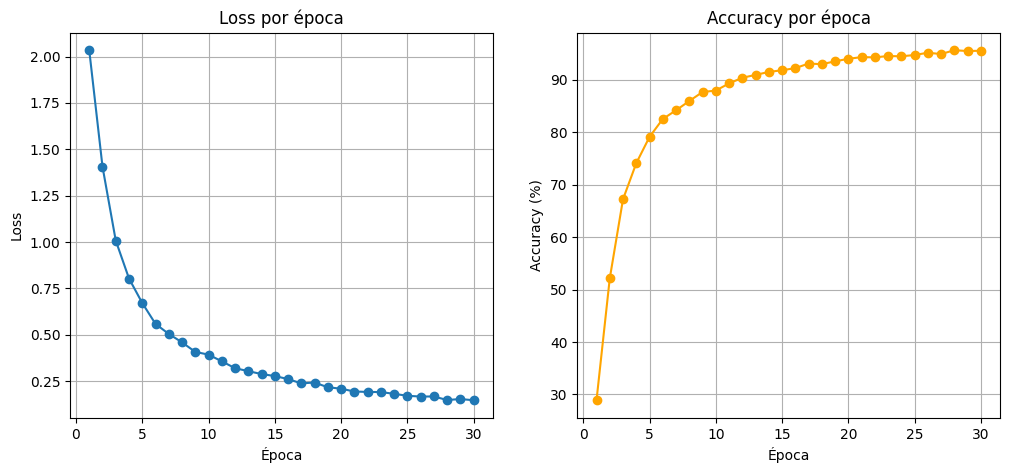

In [ ]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.plot(range(1, len(train_loss_list)+1), train_loss_list, marker='o')
plt.title('Loss por época')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1,3,2)
plt.plot(range(1, len(train_acc_list)+1), train_acc_list, marker='o', color='orange', label='Train')
plt.title('Train Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.legend()

plt.subplot(1,3,3)
plt.plot(range(1, len(test_acc_list)+1), test_acc_list, marker='o', color='green', label='Test')
plt.title('Test Accuracy por época')
plt.xlabel('Época')
plt.ylabel('Test Accuracy (%)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


prediccion con una imagen

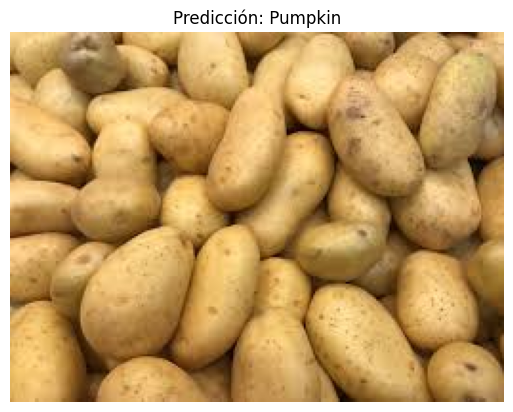

Predicted class index: 12
Predicted class name: Pumpkin


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/papas.jpg"
image = Image.open(image_path).convert('RGB')

inference_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

input_image = inference_transforms(image).unsqueeze(0)


model.eval()
with torch.no_grad():
    input_image = input_image.to(device)
    output = model(input_image)


_, predicted_idx = torch.max(output.data, 1)


class_names = test_set.classes


predicted_class = class_names[predicted_idx.item()]


plt.imshow(image)
plt.title(f"Predicción: {predicted_class}")
plt.axis('off')
plt.show()

print(f"Predicted class index: {predicted_idx.item()}")
print(f"Predicted class name: {predicted_class}")

In [ ]:
torch.save(model.state_dict(), 'modelo_vegetales.pth')